In [6]:
import pandas as pd
import networkx as nx
import re
from collections import Counter
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


# Data analyse Lido netwerk

## Let op

* Wij bekijken alleen de **verwijzingen**, dus de pijlen in het netwerk
* Een knoop waar geen verwijzing vanuit gaat **en** geen binnenkomt, komt niet in dit netwerk voor.

In [7]:
%%time
df= pd.read_csv('LidoLinks.csv.gz', header=None)
print(df.shape)
df.head()


(7355861, 2)
CPU times: total: 10.8 s
Wall time: 10.9 s


,0,1
0,jurisprudentie/id/ECLI:NL:RBAMS:2015:6776,bwb/id/BWBR0001854/2967974/1984-05-01/1984-05-01
1,jurisprudentie/id/ECLI:NL:RBOBR:2018:4470,bwb/id/BWBR0005290/2913524/2018-07-28/2018-07-28
2,jurisprudentie/id/ECLI:NL:RBAMS:2019:4496,bwb/id/BWBR0001854/2963144/1986-05-19/1986-05-19
3,jurisprudentie/id/ECLI:NL:RBOVE:2024:2366,bwb/id/BWBR0001827/3178144/2002-01-01/2002-01-01
4,jurisprudentie/id/ECLI:NL:RBUTR:2006:BA7009,bwb/id/BWBR0002375/2060994/2006-01-01/2006-01-01


# Normaliseren

* We willen de datums aan het eind van de `bwb/id/BWBR0001854/2967974/1984-05-01/1984-05-01` strings afhalen, en alleen bij die strings. 


In [8]:
%%time
# haal de datums van de id's af. Dit werkt alleen op de bwb/id knopen
df[1]=df[1].str.replace(r'(bwb.*?)(/[-0-9]+)?/[-0-9]+$',r'\1',regex=True) 
df[0]=df[0].str.replace(r'(bwb.*?)(/[-0-9]+)?/[-0-9]+$',r'\1',regex=True) 

CPU times: total: 24.6 s
Wall time: 25 s


In [11]:
# Er zijn 194 stukken die na normaliseren naar zichzelf verwijzen

print(len(df[df[0]==df[1]]))

df[df[0]==df[1]].groep_s.value_counts()

194


groep_s
uitvoeringsinformatie        171
uwv-uitvoeringsinformatie     14
jurisprudentie                 9
Name: count, dtype: int64

# Kruistabel van verwijzingen tussen soorten documenten

* De tabel toont het aantal verwijzingen van documenten in een soort op de rij naar een soort op de kolommen.
* Er zijn dus 3.849.177 verwijzingen van jurisprudentie documenten naar bwb documenten.

In [10]:
df['groep_s']=df[0].str.replace(r'/id.*',r'',regex=True) 
df['groep_t']=df[1].str.replace(r'/id.*',r'',regex=True) 
kindsOUT= list(df.groep_s.value_counts().index)+['eu-regelgeving','oep']
kindsIN=list(df.groep_t.value_counts().index)+['voorlichting-avb','beleidsregel']
print(kindsIN)
S= pd.Categorical(df.groep_s, categories=kindsIN)
T= pd.Categorical(df.groep_t, categories=kindsIN)
kruis=pd.crosstab(S,T,dropna=False,margins=True)
kruis.index.name='source'
kruis.columns.name='target'
kruis

['bwb', 'jurisprudentie', 'oep', 'eu-regelgeving', 'uitvoeringsinformatie', 'uwv-uitvoeringsinformatie', 'voorlichting-avb', 'beleidsregel']


target,bwb,jurisprudentie,oep,eu-regelgeving,uitvoeringsinformatie,uwv-uitvoeringsinformatie,voorlichting-avb,beleidsregel,All
source,,,,,,,,,
bwb,692113,0,1145662,35188,0,0,0,0,1872963
jurisprudentie,3849177,1353673,92985,93069,0,0,0,0,5388904
oep,0,0,0,0,0,0,0,0,0
eu-regelgeving,0,0,0,0,0,0,0,0,0
uitvoeringsinformatie,70835,440,419,0,19191,0,0,0,90885
uwv-uitvoeringsinformatie,735,1,228,0,0,502,0,0,1466
voorlichting-avb,807,0,127,0,0,0,0,0,934
beleidsregel,526,173,0,10,0,0,0,0,709
All,4614193,1354287,1239421,128267,19191,502,0,0,7355861


# Inkomende verwijzingen

* Per documentsoort, welk percentage van alle inkomende verwijzingen naar die soort komt van welke soort.
* Dus bwb krijgt 15% van alle 4614193 inkomende verwijzingen van zichzelf, 83% van jurisprudentie en 2% van uitvoeringsinformatie.
* NaN op een kolom betekent dat er naar die soort **nooit** verwijzingen komen (dat is niet helemaal waar, precieser is  dat we die niet kennen).

In [12]:
kruis=pd.crosstab(S,T,dropna=False)# ,margins=True)
kruis.index.name='source'
kruis.columns.name='target'
(100 * kruis/kruis.sum()).round(0)#.astype(int)

target,bwb,jurisprudentie,oep,eu-regelgeving,uitvoeringsinformatie,uwv-uitvoeringsinformatie,voorlichting-avb,beleidsregel
source,,,,,,,,
bwb,15.0,0.0,92.0,27.0,0.0,0.0,NaN,NaN
jurisprudentie,83.0,100.0,8.0,73.0,0.0,0.0,NaN,NaN
oep,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
eu-regelgeving,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
uitvoeringsinformatie,2.0,0.0,0.0,0.0,100.0,0.0,NaN,NaN
uwv-uitvoeringsinformatie,0.0,0.0,0.0,0.0,0.0,100.0,NaN,NaN
voorlichting-avb,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
beleidsregel,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


# Uitgaande verwijzingen

* Per documentsoort, welk percentage van alle **uitgaande** verwijzingen vanuit die soort naar welke soort toegaan.
* Dus 37% van alle 1872963 verwijzingen vanuit bwb gaat naar zichzelf, 61% naar oep, en 2% naar eu-regelgeving.
* NaN op een rij betekent dat er vanuit die soort **nooit** verwijzingen komen (dat is niet helemaal waar, precieser is  dat we die niet kennen).

In [13]:
(100* (kruis.T/kruis.T.sum()).T ).round(0)

target,bwb,jurisprudentie,oep,eu-regelgeving,uitvoeringsinformatie,uwv-uitvoeringsinformatie,voorlichting-avb,beleidsregel
source,,,,,,,,
bwb,37.0,0.0,61.0,2.0,0.0,0.0,0.0,0.0
jurisprudentie,71.0,25.0,2.0,2.0,0.0,0.0,0.0,0.0
oep,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eu-regelgeving,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
uitvoeringsinformatie,78.0,0.0,0.0,0.0,21.0,0.0,0.0,0.0
uwv-uitvoeringsinformatie,50.0,0.0,16.0,0.0,0.0,34.0,0.0,0.0
voorlichting-avb,86.0,0.0,14.0,0.0,0.0,0.0,0.0,0.0
beleidsregel,74.0,24.0,0.0,1.0,0.0,0.0,0.0,0.0


# Tenslotte als percentage van alle verwijzingen

In [14]:
tot=kruis.sum().sum()
(100*kruis/tot).round(2)

target,bwb,jurisprudentie,oep,eu-regelgeving,uitvoeringsinformatie,uwv-uitvoeringsinformatie,voorlichting-avb,beleidsregel
source,,,,,,,,
bwb,9.41,0.00,15.57,0.48,0.00,0.00,0.0,0.0
jurisprudentie,52.33,18.40,1.26,1.27,0.00,0.00,0.0,0.0
oep,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0
eu-regelgeving,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0
uitvoeringsinformatie,0.96,0.01,0.01,0.00,0.26,0.00,0.0,0.0
uwv-uitvoeringsinformatie,0.01,0.00,0.00,0.00,0.00,0.01,0.0,0.0
voorlichting-avb,0.01,0.00,0.00,0.00,0.00,0.00,0.0,0.0
beleidsregel,0.01,0.00,0.00,0.00,0.00,0.00,0.0,0.0


# Waar gaan de pijlen heen?

In [15]:
(100 *kruis.sum()/tot).round(2)

target
bwb                          62.73
jurisprudentie               18.41
oep                          16.85
eu-regelgeving                1.74
uitvoeringsinformatie         0.26
uwv-uitvoeringsinformatie     0.01
voorlichting-avb              0.00
beleidsregel                  0.00
dtype: float64

# En waar komen ze vandaan?

In [ ]:
(100 *kruis.sum(1)/tot).round(2)

source
bwb                          25.46
jurisprudentie               73.26
oep                           0.00
eu-regelgeving                0.00
uitvoeringsinformatie         1.24
uwv-uitvoeringsinformatie     0.02
voorlichting-avb              0.01
beleidsregel                  0.01
dtype: float64

# Out en in

* Let op, voor de stats.
* Ik bereken hier de stats van Outdegree alleen over knopen die minimaal 1 inkomende verwijzing hebben.
* Net als voor indegree

## Let op

* 204.633 hebben outdegree 0, tegen 1.423.824 minstens 1
* 1.008.960 hebben indegree 0, tegen maar 619.497 minstens 1

In [ ]:
Outdegree,Indegree=df[0].value_counts() , df[1].value_counts()

In [ ]:
# Knopen in het netwerk zonder inkomende pijl

print(len(set(Indegree.index)-set(Outdegree.index)), len(set(Outdegree.index)))
print(len(set(Outdegree.index)-set(Indegree.index)), len(set(Indegree.index)))

204633 1423824
1008960 619497


In [ ]:
Indegree.describe().round(0)

count    619497.0
mean         12.0
std         299.0
min           1.0
25%           1.0
50%           1.0
75%           3.0
max      147088.0
Name: count, dtype: float64

In [ ]:
# top 10 docs met hoogste indegree 
Indegree.head(100)

1
bwb/id/BWBR0005537/2816734        147088
bwb/id/BWBR0006358/858464          59609
bwb/id/BWBR0005537/2816444         47656
bwb/id/BWBR0001854/2963874         35538
bwb/id/BWBV0001000/10002355104     35077
                                   ...  
bwb/id/BWBR0001903/3011654          5913
bwb/id/BWBR0001854/2963254          5861
bwb/id/BWBR0001854/2967874          5811
bwb/id/BWBR0001854/2963284          5740
bwb/id/BWBR0005537/2814904          5676
Name: count, Length: 100, dtype: int64

In [ ]:
Outdegree.describe().round(0)

count    1423824.0
mean           5.0
std           51.0
min            1.0
25%            1.0
50%            3.0
75%            6.0
max        56208.0
Name: count, dtype: float64

In [ ]:
Outdegree.head(10)

0
bwb/id/BWBR0002063/2625264     56208
bwb/id/BWBR0026204/10123054    16165
bwb/id/BWBR0005537/11995284     9597
bwb/id/BWBR0002063/2625274      6877
bwb/id//11995284                3691
bwb/id/BWBR0020418/8670474      1961
bwb/id/BWBR0042991/15244314     1715
bwb/id/BWBR0024957/9801594      1633
bwb/id/BWBR0002559/1731514      1613
bwb/id/BWBR0020368/8654364      1412
Name: count, dtype: int64

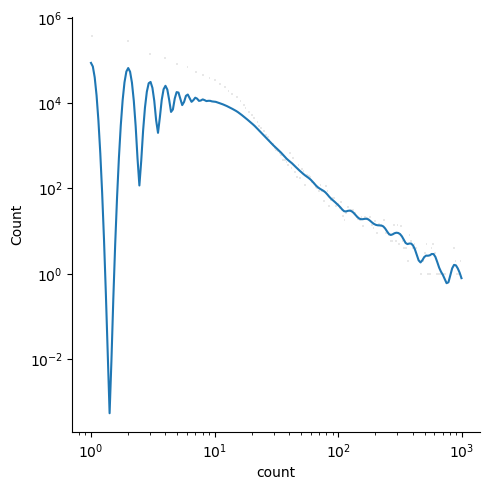

In [ ]:
# dit lijkt ook wel machtsverdeeld
sns.displot(Outdegree[Outdegree<=1000] ,kde=True,log_scale=(True,True));

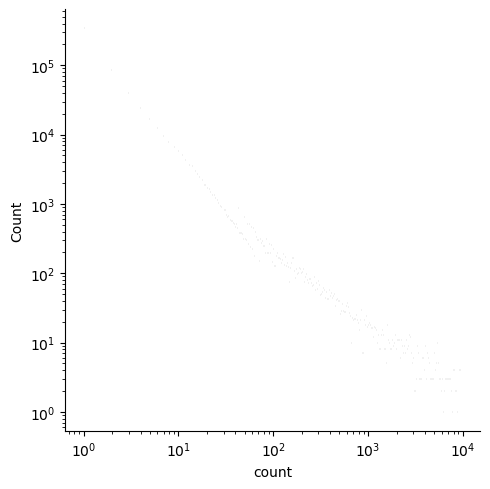

In [ ]:
# lijkt toch heel erg powerlaw verdeeld
sns.displot(Indegree[Indegree<=10**4][Indegree>=1] ,kde=False,log_scale=(True,True) );

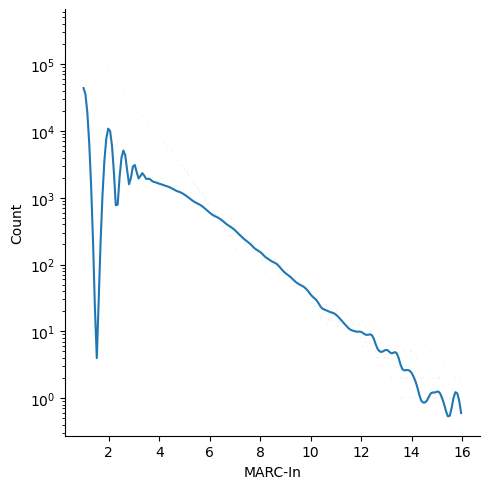

In [ ]:
marc_in= pd.Series(1+ np.log2(Indegree))
marc_in.name='MARC-In'
sns.displot(marc_in[marc_in<=16],kde=True,log_scale=(False,True) );

# Einde in- en uit-degrees

In [ ]:
%%time
# maak het netwerk
G= nx.from_pandas_edgelist(df,source=0,target=1,create_using=nx.DiGraph())
node_kind={n:re.sub(r'(^.*)/id.*',r"\1",n)  for n in G}
nx.set_node_attributes(G,node_kind,"type") # waardes als bwb en jurisprudentie

CPU times: total: 31.2 s
Wall time: 31.5 s


In [ ]:
%%time
# crashed
#nx.snap_aggregation(G, node_attributes=['type'])

CPU times: total: 0 ns
Wall time: 3.34 μs


# Prefixes en suffixes

* De prefixes als 'bwb/id' zijn niet nodig in de permanente identifier.
* Ze geven alleen het type knoop weer, er zijn er 8 van. 
* Elke knoop heeft zo'n type prefix.
* We kunnen dat dus beter als type meegeven, en er de knopen mee kleuren.

In [ ]:
# prefixes

df2=pd.DataFrame(Counter([re.sub(r'(^.*/id).*',r"\1",n) for n in G.nodes]).most_common(10))
print(df2[1].sum()==len(G.nodes))
df2.columns=['Soort legal document','Aantal knopen']
df2

True


,Soort legal document,Aantal knopen
0,jurisprudentie/id,930685
1,bwb/id,579214
2,oep/id,73156
3,uitvoeringsinformatie/id,39893
4,eu-regelgeving/id,4532
5,voorlichting-avb/id,548
6,beleidsregel/id,219
7,uwv-uitvoeringsinformatie/id,210


In [ ]:
#suffixes

len([re.sub(r'^.*/id',"",n) for n in G.nodes]), len(G.nodes)

(1628457, 1628457)

In [ ]:
# hoelang zijn die suffixes: dus 1 of 2 lang. Die van lengte 2 zijn precies de bwb/id.

Counter([len(re.sub(r'^.*/id',"",n).split('/'))-1  for n in G.nodes])

Counter({1: 1049243, 2: 579214})

In [ ]:
%%time
#SCC
largest = max(nx.strongly_connected_components(G), key=len)
len(largest) , len(largest)/G.number_of_nodes()

CPU times: total: 14.9 s
Wall time: 15.1 s


(608, 0.0003733595667555238)

In [ ]:
# wat voor soort legal docs zitten er in het SCC
Counter([re.sub(r'(^.*/id).*',r"\1",n) for n in largest]).most_common(10)

[('bwb/id', 608)]

In [ ]:
%%time
# weakly conected component
largest_weak = max(nx.weakly_connected_components(G), key=len)
len(largest_weak) , len(largest_weak)/G.number_of_nodes()

CPU times: total: 7.08 s
Wall time: 7.14 s


(1504497, 0.9238788620147784)

In [ ]:
G.number_of_edges(), G.number_of_nodes()

(6917225, 1628457)

In [ ]:
nx.density(G)

2.608432354132815e-06

In [ ]:
In=sorted(G.in_degree, key=lambda x: x[1], reverse=True)
Out=sorted(G.out_degree, key=lambda x: x[1], reverse=True)

In [ ]:
len(In), In[:20], len(Out), Out[:20]

(1628457,
 [('bwb/id/BWBR0005537/2816734', 141244),
  ('bwb/id/BWBR0006358/858464', 59552),
  ('bwb/id/BWBR0005537/2816444', 47594),
  ('bwb/id/BWBR0001854/2963874', 35526),
  ('bwb/id/BWBV0001000/10002355104', 35077),
  ('bwb/id/BWBR0001830/2637694', 31792),
  ('bwb/id/BWBR0001854/2970494', 31164),
  ('bwb/id/BWBR0001854/2962604', 28775),
  ('bwb/id/BWBR0001903/3010844', 28034),
  ('bwb/id/BWBR0001854/2962584', 27789),
  ('bwb/id/BWBR0001854/2962594', 27763),
  ('bwb/id/BWBR0011823/1385854', 27485),
  ('bwb/id/BWBV0001000/10002350834', 26941),
  ('bwb/id/BWBR0001854/2963294', 26838),
  ('bwb/id/BWBR0005537/2816214', 26771),
  ('bwb/id/BWBR0005537/2816534', 26725),
  ('bwb/id/BWBR0015703/5408634', 24674),
  ('bwb/id/BWBR0001854/2963064', 23724),
  ('bwb/id/BWBR0005289/2906814', 23144),
  ('jurisprudentie/id/ECLI:CE:ECHR:2023:1026JUD003380319', 21160)],
 1628457,
 [('bwb/id/BWBR0002063/2625264', 2055),
  ('bwb/id/BWBR0026204/10123054', 1221),
  ('bwb/id/BWBR0005537/11995284', 985),
  ('

# In- en out-degrees opgeteld per soort knoop

In [ ]:
Indf=pd.DataFrame([re.sub(r'(^.*/id/)(.*)',r"\1,\2",n[0]).split(',') +[n[1]] for n in In])
Outdf=pd.DataFrame([re.sub(r'(^.*/id/)(.*)',r"\1,\2",n[0]).split(',') +[n[1]] for n in Out])
Indf.shape, Outdf.shape

((1628457, 3), (1628457, 3))

In [ ]:
# klopt dus
Indf[2].sum(),Outdf[2].sum(), G.number_of_edges()

(np.int64(6917225), np.int64(6917225), 6917225)

In [ ]:
print(' totale indegree per soort ')
A=pd.DataFrame(Indf.groupby(0)[2].sum().sort_values())#ascending=False))
A.columns=['Indegree']
Indf.groupby(0)[2].describe().round(0).astype(int)

 totale indegree per soort 


,count,mean,std,min,25%,50%,75%,max
0,,,,,,,,
beleidsregel/id/,219,0,0,0,0,0,0,0
bwb/id/,579214,7,297,0,0,0,0,141244
eu-regelgeving/id/,4532,24,172,1,1,3,8,5437
jurisprudentie/id/,930685,1,28,0,0,0,1,21160
oep/id/,73156,17,91,1,2,5,14,18474
uitvoeringsinformatie/id/,39893,0,1,0,0,0,1,60
uwv-uitvoeringsinformatie/id/,210,2,3,0,1,2,3,15
voorlichting-avb/id/,548,0,0,0,0,0,0,0


In [ ]:
print(' totale outdegree per soort ')
B=pd.DataFrame(Outdf.groupby(0)[2].sum().sort_values(ascending=False))
B.columns=['Outdegree']
Outdf.groupby(0)[2].describe().round(0).astype(int)

 totale outdegree per soort 


,count,mean,std,min,25%,50%,75%,max
0,,,,,,,,
beleidsregel/id/,219,3,3,1,1,2,5,16
bwb/id/,579214,3,6,0,1,2,3,2055
eu-regelgeving/id/,4532,0,0,0,0,0,0,0
jurisprudentie/id/,930685,6,6,0,1,4,8,217
oep/id/,73156,0,0,0,0,0,0,0
uitvoeringsinformatie/id/,39893,2,2,0,1,2,3,58
uwv-uitvoeringsinformatie/id/,210,7,6,0,2,5,9,40
voorlichting-avb/id/,548,2,1,1,1,1,2,10


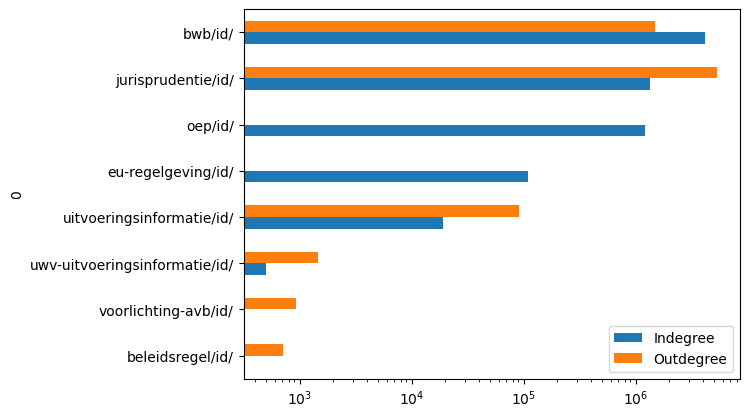

In [ ]:
A.join(B).plot(kind='barh', logx=True);

## 1. Winkels: Hoge raad

Winkels & De Ruyter (2012) rapporteren een netwerk van 15.053 uitspraken van de Hoge Raad met 106.559 verwijzingen. In het LIDO-bestand filteren op jurisprudentie type met ECLI-patronen voor de Hoge Raad.


### 1.1 Wat staat er in Winkels & De Ruyter (2012)?

Uit de paper (Winkels & de Ruyter 2012, Survival of the Fittest):

* 15.053 HR-uitspraken gepubliceerd in NJ, 1 jan 1965 – 31 dec 2008, 106.559 door hun parser gevonden referenties (F1 ≈ 99%);

* gem. in-degree ≈ 1 tot en met de jaren '80, loopt op tot ≈ 2 in de jaren 2000 

* top-10 thema's: 8 van de top-10 gaan over procesrecht, 2 over familierecht, de bekendste is Zwolsman.

Scope van hun network (belangrijk, want dat is smaller dan ons LIDO):
* alleen Hoge Raad
* alleen uitspraken gepubliceerd in NJ (Nederlandse Jurisprudentie, Kluwer);
* alleen citaties naar andere NJ-HR-uitspraken — referenties naar HR-uitspraken buiten NJ vallen weg;


### 1.2 Wat hebben wij in LIDO

We hebben geen toegang tot de originele Kluwer-dataset die in Winkels (2012) is gebruikt. Ons LIDO-netwerk is ruimer:

* alle gepubliceerde HR-uitspraken, ongeacht of ze in NJ staan (ECLI);
* niet alleen HR → HR maar alle verwijzingen, zoals HR → bwb, HR → EU, enz.;
* geldt tot ver na 2008;

### 1.3 Hoe vergelijken

4 datasets:

`G_all_HR` alle HR-uitspraken in LIDO, alle uitgaande edges, alle jaren 

`G_HR_HR` alle HR-uitspraken in LIDO, alleen HR → HR , alle jaren

`G_repro` HR-uitspraken met bronjaar ∈ [1965, 2008], HR → HR binnen die periode (beste kopie van Winkels' dataset)

`G_ext`   HR-uitspraken t/m heden, HR → HR van 1965–heden


G_repro verschillen met Winkels' dataset:

1. zij hebben alleen NJ HR-uitspraken, wij hebben alle ECLI:NL:HR-uitspraken. Dit zorgt voor een hoger aantal nodes bij ons.
2. zij herkennen NJ-referentiepatronen, wij herkennen ECLI. Wij missen cases die alleen met een NJ-nummer naar elkaar verwijzen en waar geen ECLI-mapping voor is.
3. oude HR-uitspraken die nu pas een ECLI hebben gekregen, kunnen na 2008 nog nieuwe inkomende edges hebben gekregen.




In [ ]:
# alle HR uitspraken slecteren

hr_filtered_s = df[0].str.contains(r'ECLI.NL.HR', regex=True, na=False)
hr_filtered_t = df[1].str.contains(r'ECLI.NL.HR', regex=True, na=False)



df_hr = df[hr_filtered_s & hr_filtered_t].copy()
print(f'HR->HR edges: {len(df_hr):,}')
print(f'Unieke HR nodes (source): {df_hr[0].nunique():,}')
print(f'Unieke HR nodes (target): {df_hr[1].nunique():,}')

# Alle HR nodes
all_hr_nodes = set(df_hr[0]) | set(df_hr[1])
print(f'Totaal unieke HR nodes: {len(all_hr_nodes):,}')

In [40]:
# het hele Hoge Raad subnetwerk bouwen
G_hr = nx.from_pandas_edgelist(df_hr, source=0, target=1, create_using=nx.DiGraph())
print(f'HR netwerk: {G_hr.number_of_nodes():,} nodes, {G_hr.number_of_edges():,} edges')
print(f'Dichtheid: {nx.density(G_hr):.6f}')

HR netwerk: 21,908 nodes, 26,257 edges
Dichtheid: 0.000055


In [54]:
YEAR_REGEX = re.compile(r'ECLI[.:]NL[.:][A-Z]+[.:](\d{4})[.:]')

def ecli_year(u):
    m = YEAR_REGEX.search(str(u))
    return int(m.group(1)) if m else None

bron_hr = df[0].astype(str).str.contains(r'ECLI[.:]NL[.:]HR[.:]', na=False) 
target_hr = df[1].astype(str).str.contains(r'ECLI[.:]NL[.:]HR[.:]', na=False)

print(f'edges met HR als bron: {bron_hr.sum()}')
print(f'edges met HR als target: {target_hr.sum()}')
print(f'edges HR->HR: {(bron_hr & target_hr).sum()}')
print(f'edges HR->iets anders: {(bron_hr & ~target_hr).sum()}')
print(f'edges iets anders->HR: {(~bron_hr & target_hr).sum()}')

edges met HR als bron: 263940
edges met HR als target: 466924
edges HR->HR: 26257
edges HR->iets anders: 237683
edges iets anders->HR: 440667


In [ ]:
#   G_all_HR:  elke edge die HR aan beide uiteinden heeft (HR--HR)
#   G_HR_HR:   alleen HR->HR
#   G_repro:   G_HR_HR beperkt tot 1965-2008 
#   G_ext:     G_HR_HR alle jaren t/m heden

WINKELS_START, WINKELS_END = 1965, 2008

df_hrhr = df[bron_hr & target_hr].copy()
df_hrhr['src_year'] = df_hrhr[0].map(ecli_year)
df_hrhr['tgt_year'] = df_hrhr[1].map(ecli_year)


# alle edges waar bron HR is
df_all_hr = df[bron_hr].copy()

G_all_HR = nx.from_pandas_edgelist(
    df_all_hr, source=0, target=1, create_using=nx.DiGraph()
)

# alle jaren, incl. pre-1965
G_HR_HR = nx.from_pandas_edgelist(df_hrhr, source=0, target=1, create_using=nx.DiGraph())

# alleen 1965–2008
df_repro = df_hrhr[
    df_hrhr['src_year'].between(WINKELS_START, WINKELS_END) &
    df_hrhr['tgt_year'].between(WINKELS_START, WINKELS_END)
]
G_repro = nx.from_pandas_edgelist(df_repro, source=0, target=1, create_using=nx.DiGraph())

# 1965–heden
df_ext = df_hrhr[
    (df_hrhr['src_year'] >= WINKELS_START) &
    (df_hrhr['tgt_year'] >= WINKELS_START)
]
G_ext = nx.from_pandas_edgelist(df_ext, source=0, target=1, create_using=nx.DiGraph())


# Waarden vergelijking

In [ ]:


in_deg  = dict(G_hr.in_degree())
out_deg = dict(G_hr.out_degree())

in_val  = list(in_deg.values())
out_val = list(out_deg.values())



eigen_waarden= {
    'nodes': G_hr.number_of_nodes(),
    'edges': G_hr.number_of_edges(),
    'density': round(nx.density(G_hr), 6),
    'gem. indegree': round(np.mean(in_val), 2),
    'max indegree': max(in_val),
    'gem. outdegree': round(np.mean(out_val), 2),
    'max outdegree': max(out_val),
}

print(eigen_waarden)





# waarden van Winkels uit paper
# 15.053 uitspraken, 106.559 refs (inclusief citaties NAAR HR vanuit andere courts)
#   HR->HR subset kleiner; exacte cijfers niet volledig in paper.


waarden_winkels = {
'nodes': 15053,
'edges': 106559, #'(HR→HR: 7.992)'
'density':        None,         # niet expliciet in paper
'gem. indegree':  None,
'max indegree':   None,
'gem. outdegree': None,
'max outdegree':  None,
}




vergelijking = pd.DataFrame({'ons HR-subnet': eigen_waarden,
                             'Winkels 2011/12':    waarden_winkels})
vergelijking







{'nodes': 21908, 'edges': 26257, 'density': 5.5e-05, 'gem. indegree': np.float64(1.2), 'max indegree': 183, 'gem. outdegree': np.float64(1.2), 'max outdegree': 52}


,ons LIDO-HR-subnet,Winkels 2011/12
nodes,21908.000000,15053.0
edges,26257.000000,106559.0
density,0.000055,NaN
gem. indegree,1.200000,NaN
max indegree,183.000000,NaN
gem. outdegree,1.200000,NaN
max outdegree,52.000000,NaN


G_repro (1965-2008):


,n,mean_indeg,median_indeg
decade,,,
1960,79,1.127,1.0
1970,284,1.158,1.0
1980,864,1.294,1.0
1990,2471,1.254,1.0
2000,3959,0.630,0.0



G_HR_HR (alle jaren):


,n,mean_indeg,median_indeg
decade,,,
1900,1,1.000,1.0
1910,17,1.059,1.0
1920,32,1.125,1.0
1930,45,1.133,1.0
1940,41,1.171,1.0
1950,215,1.237,1.0
1960,221,1.312,1.0
1970,384,1.328,1.0
1980,1110,1.612,1.0


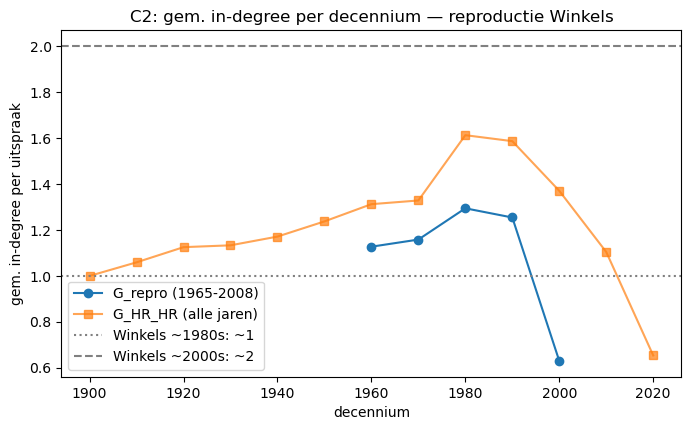

In [53]:
#in-degree per decennium

def indeg_per_decade(H):
    df2 = pd.DataFrame(H.in_degree(), columns=['node', 'indeg'])

    df2['year'] = df2['node'].map(ecli_year)
    df2 = df2.dropna(subset=['year'])
    df2['decade'] = (df2['year'] // 10) * 10

    return df2.groupby('decade')['indeg'].agg(
        n='size',
        mean_indeg='mean',
        median_indeg='median'
    ).round(3)


agg_repro = indeg_per_decade(G_repro)
agg_alle   = indeg_per_decade(G_HR_HR)

print('G_repro (1965-2008):')
display(agg_repro)
print()
print('G_HR_HR (alle jaren):')
display(agg_alle)

fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(agg_repro.index, agg_repro['mean_indeg'], marker='o', label='G_repro (1965-2008)')
ax.plot(agg_alle.index,   agg_alle['mean_indeg'],   marker='s', label='G_HR_HR (alle jaren)', alpha=0.7)
ax.axhline(1.0, color='gray', ls=':', label='Winkels ~1980s: ~1')
ax.axhline(2.0, color='gray', ls='--', label='Winkels ~2000s: ~2')
ax.set_xlabel('decennium'); ax.set_ylabel('gem. in-degree per uitspraak')
ax.set_title('C2: gem. in-degree per decennium — reproductie Winkels')
ax.legend(); plt.show()

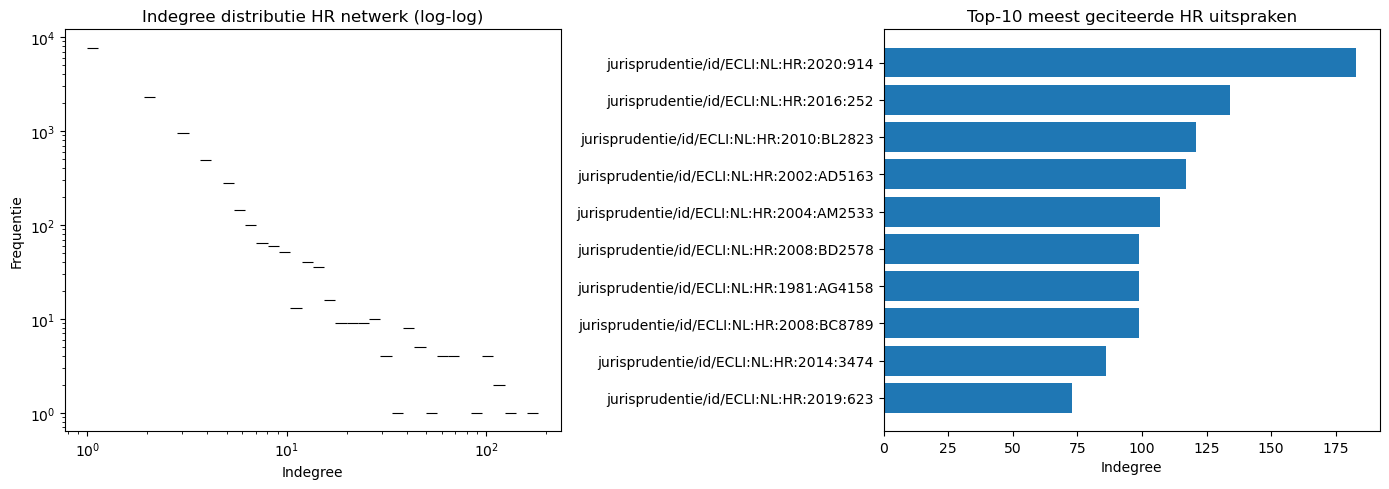

In [20]:
# Indegree distributie Hoge Raad netwerk
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Indegree
in_series = pd.Series(in_val)
sns.histplot(in_series[in_series > 0], ax=axes[0], log_scale=(True, True), bins=40)
axes[0].set_title('Indegree distributie HR netwerk (log-log)')
axes[0].set_xlabel('Indegree')
axes[0].set_ylabel('Frequentie')

# 10 meest geciteerde HR uitspraken
top10 = pd.Series(in_deg).nlargest(10)
axes[1].barh(top10.index, top10.values)
axes[1].invert_yaxis()
axes[1].set_title('Top-10 meest geciteerde HR uitspraken')
axes[1].set_xlabel('Indegree')

plt.tight_layout()
plt.show()


## 2 Hele netwerk

In [21]:
G = nx.from_pandas_edgelist(df, source=0, target=1, create_using=nx.DiGraph())
print(f'hele netwerk: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')
print(f'dichtheid: {nx.density(G):.8f}')

hele netwerk: 1,628,457 nodes, 6,917,225 edges
dichtheid: 0.00000261


## 3. Homofilie 